# Problem-Statement Labeling — Original vs Labeled

This notebook runs the classical labeling pipeline **exactly as written in the problem statement** and shows the original image next to its label.

| Problem statement step | What happens here |
|---|---|
| Global Cell Segmentation | Gaussian smoothing, then Otsu threshold → solid binary mask of the cellular footprint |
| Boundary Band Definition | Erode the footprint by a pixel radius, subtract → peripheral ring |
| HoG based labelling | HOG-style gradient-orientation histograms → map of oriented edge strength |
| Targeted Intensity Thresholding | Higher-intensity threshold applied **only inside the band** |
| Binary Mask Extraction | Cleaned final binary mask |

Needs only `label_statement.py` next to this notebook (no `config.py`, no TensorFlow).

In [1]:
import os
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import replace

from label_statement import (Params, label_path, list_images,
                             make_overlay, build_panel_figure)

# ---- EDIT THIS: folder containing your .tif images -------------------------
INPUT_DIR = "data/raw"
# ----------------------------------------------------------------------------

P = Params()          # default parameters; see label_statement.Params for all knobs
image_paths = list_images(INPUT_DIR)
print(f"Found {len(image_paths)} image(s) in '{INPUT_DIR}'")
for p in image_paths:
    print("  ", os.path.basename(p))

Found 6 image(s) in 'data/raw'
   1.tif
   2.tif
   3.tif
   4.tif
   5.tif
   6.tif


## 1. Original vs Labeled — every image
Left: original. Middle: final binary mask. Right: mask overlaid in green.

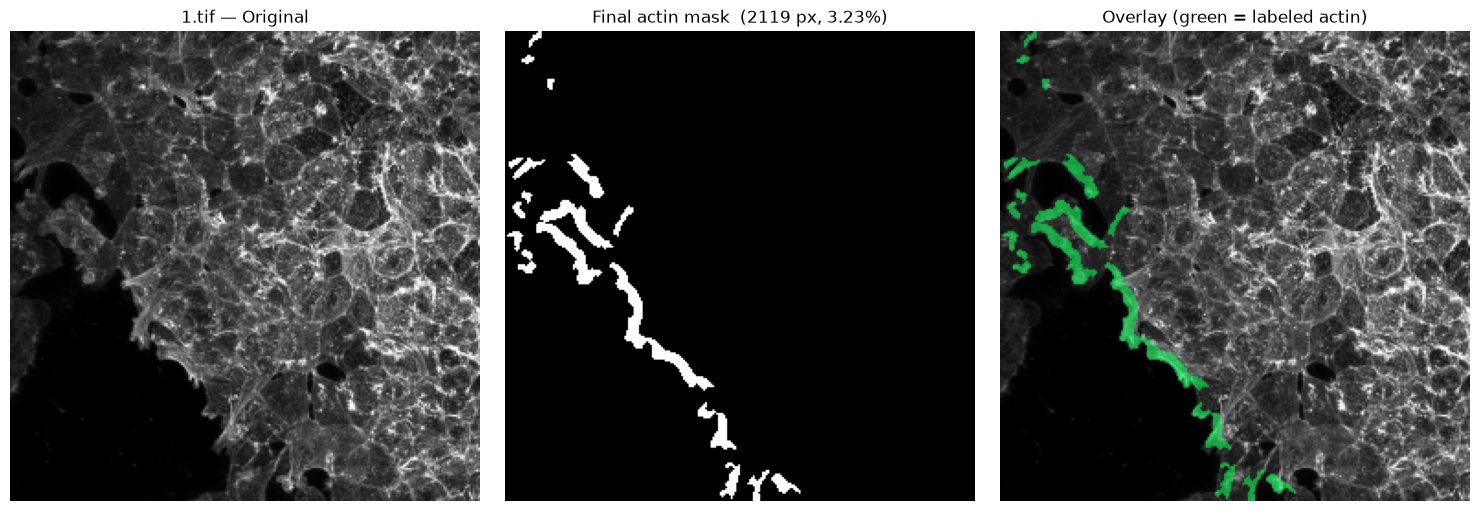

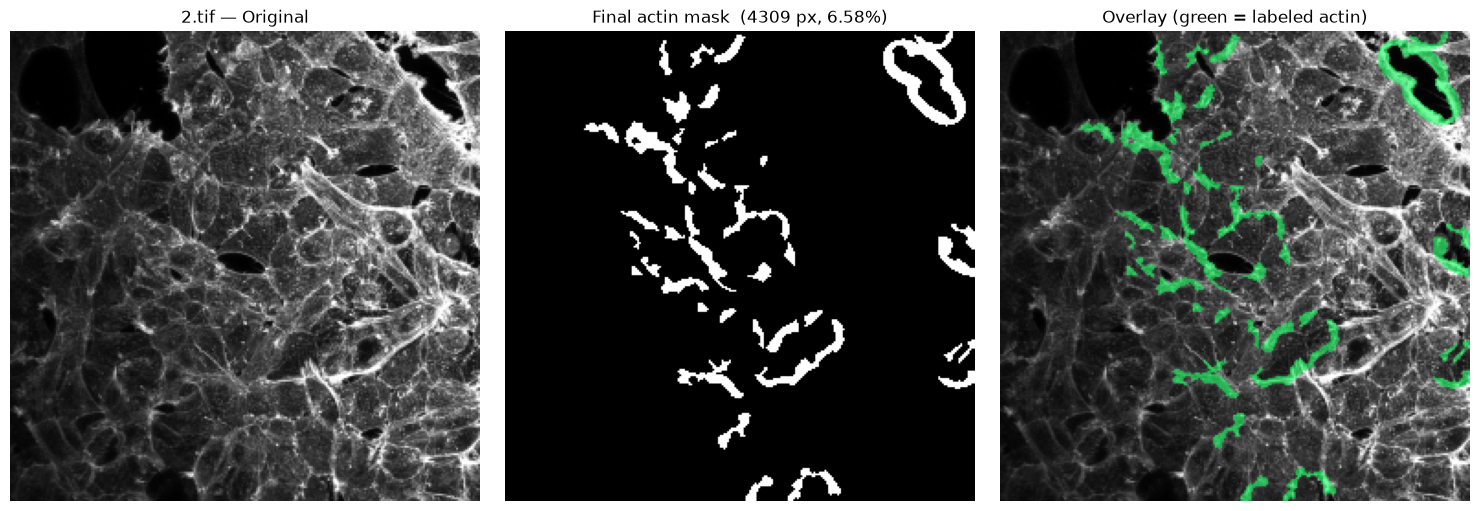

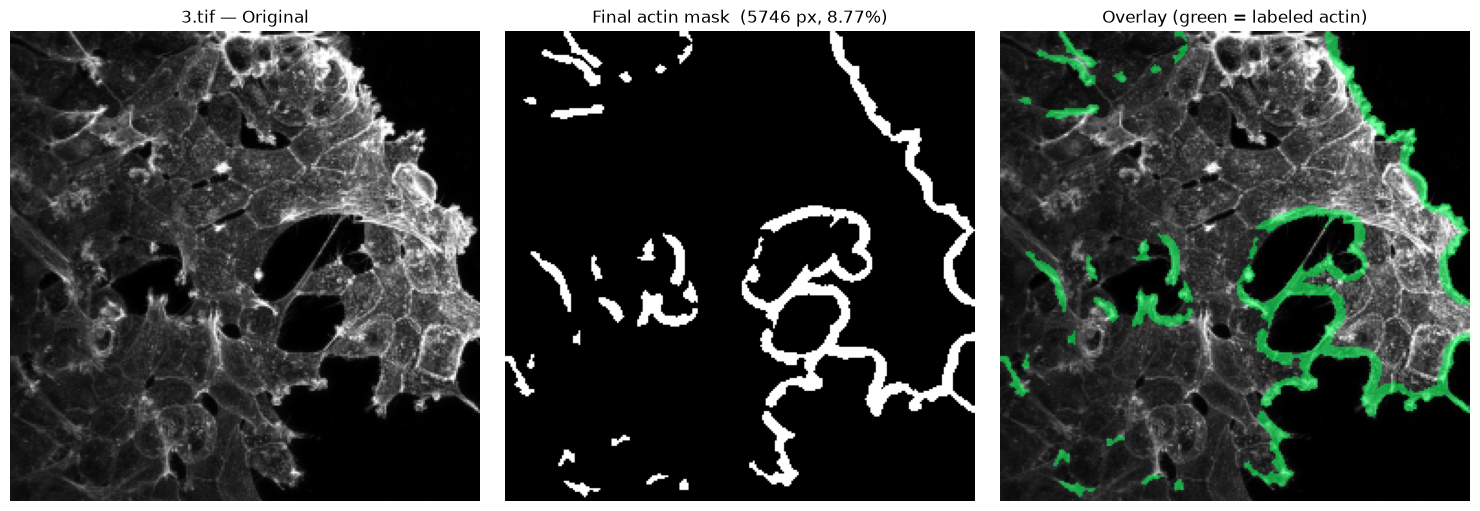

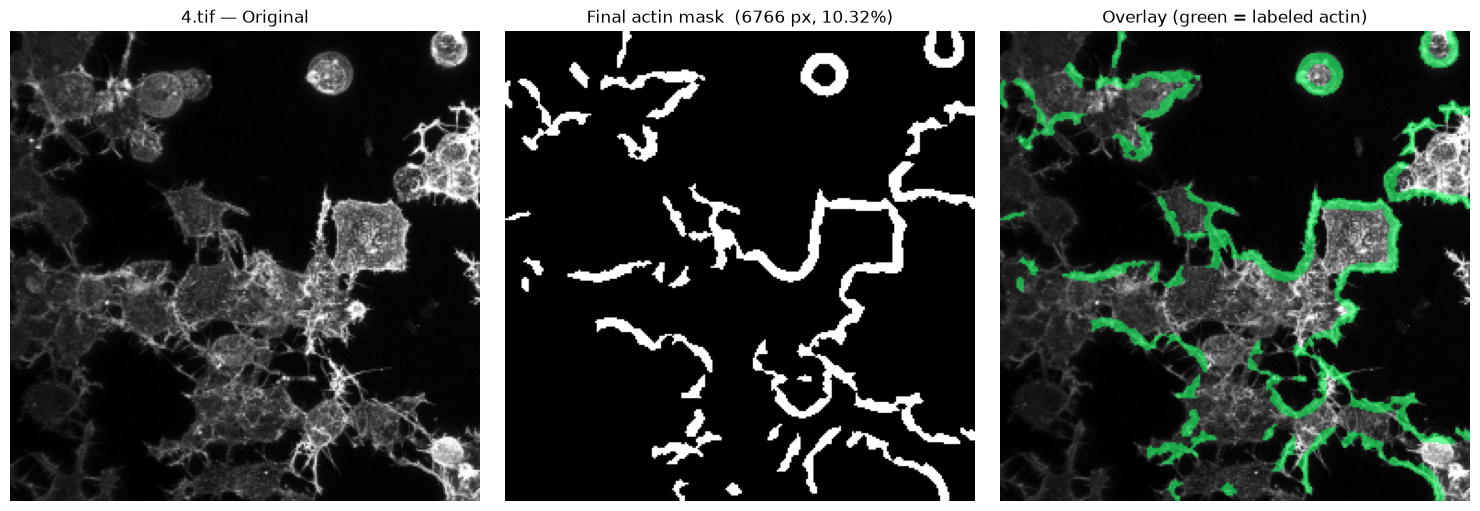

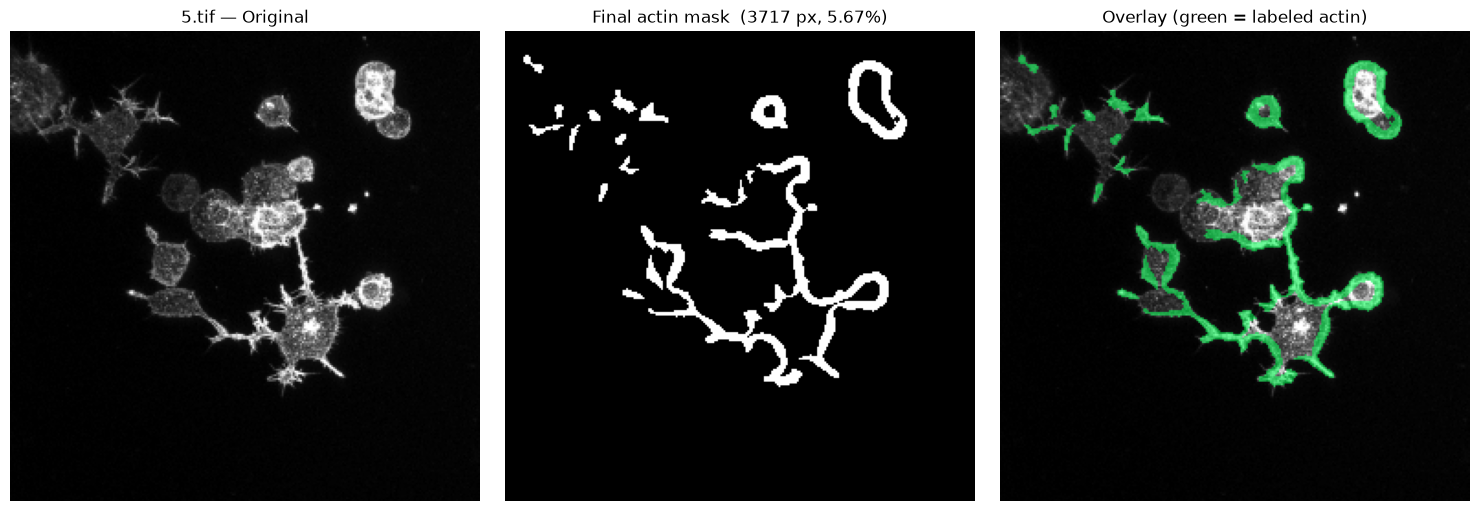

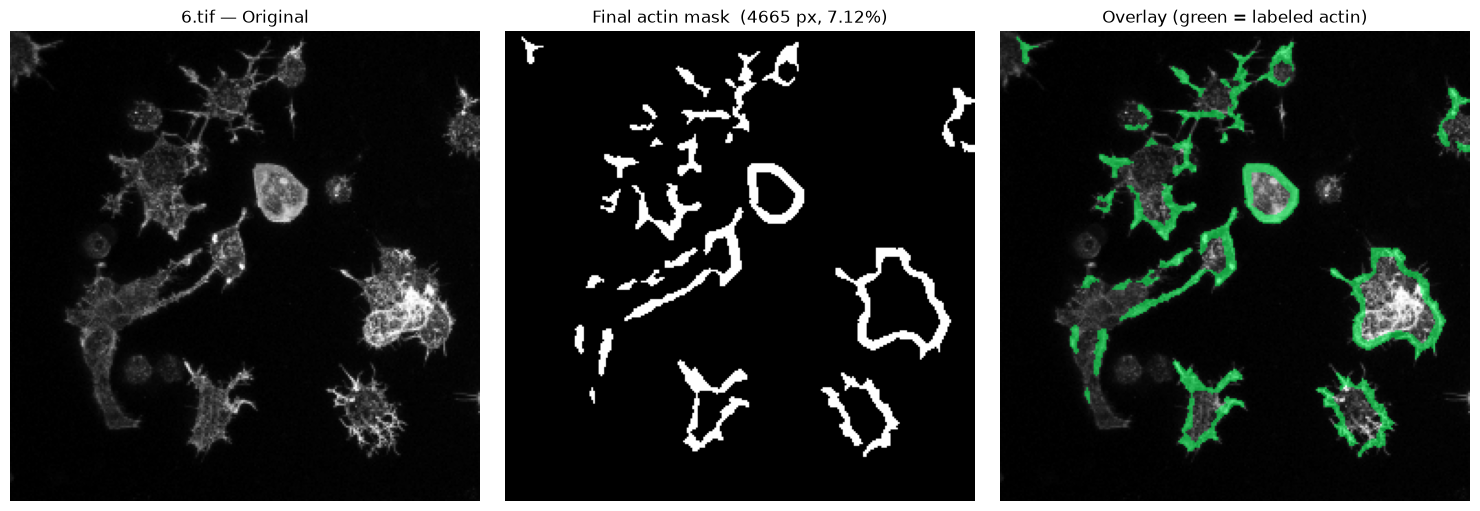

In [2]:
results = {}
for path in image_paths:
    name = os.path.basename(path)
    out = label_path(path, P)
    results[name] = out

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(out["image"], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"{name} — Original", fontsize=12)
    axes[1].imshow(out["mask"], cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Final actin mask  ({out['actin_pixels']} px, {out['actin_percent']:.2f}%)", fontsize=12)
    axes[2].imshow(make_overlay(out["image"], out["mask"]))
    axes[2].set_title("Overlay (green = labeled actin)", fontsize=12)
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 2. Every intermediate stage
Use this one for the *labeled data / algorithm* slide — it shows each step of the problem statement.

In [ ]:
for name, out in results.items():
    fig = build_panel_figure(out, title=name)
    plt.show()

## 3. Statistics table

In [ ]:
rows = []
for name, out in results.items():
    rows.append({
        "image": name,
        "footprint_%": round(out["footprint"].mean() * 100, 1),
        "band_px": int(out["band"].sum()),
        "band_intensity_thr": round(out["band_threshold"], 3),
        "actin_px": out["actin_pixels"],
        "actin_%": round(out["actin_percent"], 2),
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False))

## 4. Tuning — compare settings on one image
Change `IMAGE_NAME`, then look at how the mask changes. Pick the setting whose green overlay follows the real bright cell-edge actin best, and copy those values into `Params` in `label_statement.py`.

In [ ]:
IMAGE_NAME = os.path.basename(image_paths[0])      # <- change to any file name above
path = os.path.join(INPUT_DIR, IMAGE_NAME)

variants = {
    "default":                 P,
    "band radius 5":           replace(P, band_radius_px=5),
    "band radius 12":          replace(P, band_radius_px=12),
    "stricter intensity (70)": replace(P, band_percentile=70),
    "Otsu inside band":        replace(P, band_threshold_mode="otsu"),
    "HOG off":                 replace(P, use_hog=False),
}

n = len(variants)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(5.2 * ((n + 1) // 2), 10))
for ax, (label, params) in zip(axes.ravel(), variants.items()):
    o = label_path(path, params)
    ax.imshow(make_overlay(o["image"], o["mask"], alpha=0.8))
    ax.set_title(f"{label}\n{o['actin_pixels']} px ({o['actin_percent']:.2f}%)", fontsize=11)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. What to change if the mask looks wrong

| Symptom | Parameter in `Params` | Change |
|---|---|---|
| Footprint (stage 3) is fragmented or misses parts of the cell sheet | `footprint_sigma` | raise (e.g. 4–5) |
| Footprint swallows the dark background | `footprint_otsu_scale` | raise above 1.0 |
| Footprint misses dim cells | `footprint_otsu_scale` | lower below 1.0 |
| Band too thin / too thick | `band_radius_px` | raise / lower |
| Too few actin pixels | `band_percentile` | lower (e.g. 40) |
| Too much non-actin labeled | `band_percentile` | raise (e.g. 70) |
| Speckle noise in the mask | `hog_percentile` or `final_min_object_px` | raise |
| Dark gaps inside the sheet should (not) get their own rim | `footprint_fill_hole_px` | lower to keep gaps, raise to fill them |

**Limitation of this method (worth stating in the presentation):** the band is built from the outer edge of the Otsu footprint, so it labels actin at the **periphery of the cell sheet and around large gaps**. Actin at cell–cell junctions *inside* a packed monolayer lies inside the footprint and is not part of this label — that is what the Frangi pipeline captures.